In [48]:
#@markdown ---
#@markdown ## Pull UniProt sequences by: (1) single UniProt accession OR (2) Pfam family OR (3) InterPro family
#@markdown ---

import requests
from statistics import median

# ----------------------------
# Parameters
# ----------------------------

MODE = "pfam"  #@param ["accession", "pfam", "interpro"]

ACCESSION = "A0A060VPW7"   #@param {type:"string"}   # UniProt accession (e.g., P01234, Q9XYZ1, A0A060VPW7)
PFAM_ID   = "PF00741"      #@param {type:"string"}   # Pfam ID (e.g., PF00001)
INTERPRO_ID = "IPR000638"  #@param {type:"string"}   # InterPro ID (e.g., IPR000532)

REVIEWED_ONLY = False   #@param {type:"boolean"}
TAXON_ID = ""          #@param {type:"string"}  # e.g. 9606 for human, blank for all
MIN_LEN = 0            #@param {type:"integer"}  # 0 disables lower bound
MAX_LEN = 80            #@param {type:"integer"}  # 0 disables upper bound
OUT_FASTA = ""         #@param {type:"string"}   # blank = auto name

TIMEOUT_S = 180        #@param {type:"integer"}  # request timeout in seconds

# ----------------------------
# Helper: parse FASTA lengths
# ----------------------------
def fasta_stats(fasta_text: str):
    fasta_text = fasta_text.strip()
    if not fasta_text:
        return 0, []

    headers = [l for l in fasta_text.splitlines() if l.startswith(">")]
    n_seq = len(headers)

    seqs = []
    cur = []
    for line in fasta_text.splitlines():
        if line.startswith(">"):
            if cur:
                seqs.append("".join(cur))
                cur = []
        else:
            cur.append(line.strip())
    if cur:
        seqs.append("".join(cur))

    lengths = [len(s) for s in seqs]
    return n_seq, lengths

def apply_length_filter_to_query(query: str, min_len: int, max_len: int) -> str:
    if min_len and max_len:
        return query + f" AND length:[{min_len} TO {max_len}]"
    elif min_len and not max_len:
        return query + f" AND length:[{min_len} TO *]"
    elif max_len and not min_len:
        return query + f" AND length:[1 TO {max_len}]"
    return query

# ----------------------------
# MODE 1: single UniProt accession
# ----------------------------
MODE = MODE.strip().lower()

if MODE == "accession":
    acc = ACCESSION.strip()
    if not acc:
        raise ValueError("ACCESSION is blank. Provide a UniProt accession like A0A060VPW7.")

    url = f"https://rest.uniprot.org/uniprotkb/{acc}.fasta"
    print("Mode: ACCESSION")
    print("Requesting:", url)

    r = requests.get(url, timeout=TIMEOUT_S)
    print("HTTP status:", r.status_code)

    if not r.ok:
        print("Error retrieving data:")
        print(r.text[:800])
        raise SystemExit()

    fasta_text = r.text.strip()
    n_seq, lengths = fasta_stats(fasta_text)

    print("Total sequences returned:", n_seq)
    if lengths:
        print("Length:", lengths[0])

    # optional: enforce min/max length in accession mode by dropping output
    if MIN_LEN and lengths and lengths[0] < MIN_LEN:
        print(f"WARNING: sequence length {lengths[0]} < MIN_LEN {MIN_LEN}. Not writing FASTA.")
        raise SystemExit()
    if MAX_LEN and lengths and lengths[0] > MAX_LEN:
        print(f"WARNING: sequence length {lengths[0]} > MAX_LEN {MAX_LEN}. Not writing FASTA.")
        raise SystemExit()

    if not OUT_FASTA.strip():
        OUT_FASTA = f"{acc}.fasta"

    with open(OUT_FASTA, "w") as out:
        out.write(fasta_text)
    print("Wrote:", OUT_FASTA)

# ----------------------------
# MODE 2/3: stream by Pfam or InterPro family
# ----------------------------
elif MODE in ("pfam", "interpro"):
    if MODE == "pfam":
        pid = PFAM_ID.strip()
        if len(pid) != 7 or not pid.startswith("PF"):
            raise ValueError("PFAM_ID must look like PF00001")
        base = f"xref:pfam-{pid}"
        label = pid

    else:  # interpro
        iid = INTERPRO_ID.strip()
        if len(iid) != 9 or not iid.startswith("IPR"):
            raise ValueError("INTERPRO_ID must look like IPR000532")
        base = f"xref:interpro-{iid}"
        label = iid

    query = base

    if REVIEWED_ONLY:
        query += " AND reviewed:true"

    if TAXON_ID.strip():
        query += f" AND taxonomy_id:{TAXON_ID.strip()}"

    query = apply_length_filter_to_query(query, MIN_LEN, MAX_LEN)

    print(f"Mode: {MODE.upper()} STREAM")
    print("Query:")
    print(" ", query)

    url = "https://rest.uniprot.org/uniprotkb/stream"
    params = {"query": query, "format": "fasta"}

    r = requests.get(url, params=params, timeout=TIMEOUT_S)
    print("HTTP status:", r.status_code)

    if not r.ok:
        print("Error retrieving data:")
        print(r.text[:800])
        raise SystemExit()

    fasta_text = r.text.strip()
    n_seq, lengths = fasta_stats(fasta_text)

    print("Total sequences returned:", n_seq)
    if n_seq == 0:
        print("WARNING: No sequences found.")
        raise SystemExit()

    print("Min length:", min(lengths))
    print("Median length:", int(median(lengths)))
    print("Max length:", max(lengths))

    if not OUT_FASTA.strip():
        OUT_FASTA = f"{PFAM_ID}.fasta"

    with open(OUT_FASTA, "w") as out:
        out.write(fasta_text)
    print("Wrote:", OUT_FASTA)

else:
    raise ValueError("MODE must be one of: 'accession', 'pfam', 'interpro'")

Mode: PFAM STREAM
Query:
  xref:pfam-PF00741 AND length:[1 TO 80]
HTTP status: 200
Total sequences returned: 1931
Min length: 27
Median length: 71
Max length: 80
Wrote: PF00741.fasta


In [49]:
#@markdown ---
#@markdown # Setup + Generation Control Parameters
#@markdown ---

import os, re, json, math, random, textwrap
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm

#@markdown ---
#@markdown ## Reproducibility
#@markdown ---
LM_SEED = 0  #@param {type:"integer"}
random.seed(LM_SEED)
np.random.seed(LM_SEED)
torch.manual_seed(LM_SEED)
torch.cuda.manual_seed_all(LM_SEED)

#@markdown ---
#@markdown ## Device
#@markdown ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

#@markdown ---
#@markdown ## Final Output Controls
#@markdown ---
FINAL_KEEP = 10  #@param {type:"integer"}  # final sequences retained after all filtering
RANK_KEEP  = 100 #@param {type:"integer"}  # top-N after scoring (recommend ~10x FINAL_KEEP)
N_ACCEPT   = 100 #@param {type:"integer"}  # number accepted before ranking (recommend ~10x FINAL_KEEP)

#@markdown ---
#@markdown ## Sampling Batch Controls
#@markdown ---
BATCH_SIZE  = 1024     #@param {type:"integer"}  # sequences generated per batch
MAX_SAMPLED = 200000   #@param {type:"integer"}  # hard cap on total sampled sequences

#@markdown ---
#@markdown ## Sampling Controls
#@markdown ---
TEMPERATURE = 0.7  #@param {type:"number"}  # higher = more diverse
TOP_P       = 0.9  #@param {type:"number"}  # nucleus threshold (0.8–0.95 typical)

#@markdown ---
#@markdown ## Sequence Constraints
#@markdown ---
MIN_LEN       = 20   #@param {type:"integer"}  # adjust to your domain family
NLL_THRESHOLD = 3.1  #@param {type:"number"}   # lower = more natural

#@markdown ---
#@markdown ## Novelty Controls
#@markdown ---
NOVELTY_SOFT_THRESHOLD = 0.9  #@param {type:"number"}  # lower = more novel
NOVELTY_WEIGHT         = 0.5   #@param {type:"number"}  # how strongly novelty influences ranking

#@markdown ---
#@markdown ## Monitoring
#@markdown ---
STATUS_EVERY = 1000  #@param {type:"integer"}  # print progress every N sampled
kmer_size    = 7     #@param {type:"integer"}  # k-mer size for novelty

AUTO_RELAX = True  #@param {type:"boolean"}  # relax constraints if nothing passes

#@markdown ---
#@markdown ## Alphabet (standard 20 AAs)
#@markdown ---
aa_alphabet = "ACDEFGHIKLMNPQRSTVWY"

Device: cuda


In [50]:
#@markdown ---
#@markdown ## Load PFAM slices FASTA → seqs list (LM-ready)
#@markdown ---

IN_FASTA = f"{PFAM_ID}.fasta"  #@param {type:"string"}
aa_alphabet = "ACDEFGHIKLMNPQRSTVWY"

seqs = []
with open(IN_FASTA, "r") as f:
    cur = None
    buf = []
    for line in f:
        line = line.strip()
        if line.startswith(">"):
            if buf:
                s = "".join(buf).upper()
                if s and all(c in aa_alphabet for c in s):
                    seqs.append(s)
            buf = []
        else:
            buf.append(line)
    if buf:
        s = "".join(buf).upper()
        if s and all(c in aa_alphabet for c in s):
            seqs.append(s)

print("Loaded sequences:", len(seqs))
print("Min/median/max len:", min(map(len, seqs)), sorted(map(len, seqs))[len(seqs)//2], max(map(len, seqs)))

Loaded sequences: 1929
Min/median/max len: 27 71 80


In [51]:

import os, re, json, math, random, textwrap
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm
#@markdown ---
#@markdown # Tokenization + Dataset
#@markdown ---
LM_PAD = 0
LM_AA_OFFSET = 1  # AAs are 1..20
LM_BOS = 21
LM_EOS = 22
LM_VOCAB = 23

lm_aa_to_id = {aa: i + LM_AA_OFFSET for i, aa in enumerate(aa_alphabet)}
lm_id_to_aa = {i + LM_AA_OFFSET: aa for i, aa in enumerate(aa_alphabet)}
lm_id_to_aa[LM_BOS] = "<BOS>"
lm_id_to_aa[LM_EOS] = "<EOS>"
lm_id_to_aa[LM_PAD] = "<PAD>"

# Robust LM_MAX_LEN (avoid one outlier bloating pos_emb)
lens = np.array([len(s) for s in seqs], dtype=int)
p99 = int(np.percentile(lens, 99))
LM_MAX_LEN = min(280, p99 + 2)  # +2 for BOS/EOS
LM_MAX_LEN = max(LM_MAX_LEN, 32)
LM_MAX_LEN_INP = LM_MAX_LEN - 1  # model input length (x[:-1])
print("LM_MAX_LEN:", LM_MAX_LEN, "| p99_len:", p99, "| N_seqs:", len(seqs))

def lm_encode(seq: str, max_len: int):
    bad = [a for a in seq if a not in lm_aa_to_id]
    if bad:
        raise ValueError(f"Nonstandard AAs {set(bad)} found. Fix upstream filters or extend vocab.")
    toks = [LM_BOS] + [lm_aa_to_id[a] for a in seq] + [LM_EOS]
    toks = toks[:max_len]
    arr = np.full((max_len,), LM_PAD, dtype=np.int64)
    arr[:len(toks)] = np.array(toks, dtype=np.int64)
    return arr

class LMDataset(Dataset):
    def __init__(self, seqs, max_len):
        self.seqs = seqs
        self.max_len = max_len
    def __len__(self):
        return len(self.seqs)
    def __getitem__(self, idx):
        x = lm_encode(self.seqs[idx], self.max_len)
        inp = torch.tensor(x[:-1], dtype=torch.long)
        tgt = torch.tensor(x[1:], dtype=torch.long)
        return inp, tgt


LM_MAX_LEN: 82 | p99_len: 80 | N_seqs: 1929


In [52]:


#@markdown ---
#@markdown # Define TinyGPT Model
#@markdown ---

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


class CausalSelfAttentionBlock(nn.Module):
    def __init__(self, d_model, nhead, dim_ff, dropout):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model)
        self.attn = nn.MultiheadAttention(d_model, nhead, dropout=dropout, batch_first=True)
        self.ln2 = nn.LayerNorm(d_model)
        self.ff = nn.Sequential(
            nn.Linear(d_model, dim_ff),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(dim_ff, d_model),
            nn.Dropout(dropout),
        )
    def forward(self, x, attn_mask):
        h = self.ln1(x)
        a, _ = self.attn(h, h, h, attn_mask=attn_mask, need_weights=False)
        x = x + a
        x = x + self.ff(self.ln2(x))
        return x

class TinyGPT(nn.Module):
    def __init__(self, vocab_size, d_model=256, nhead=8, n_layers=4, dim_ff=1024, dropout=0.1, max_seq_len=LM_MAX_LEN):
        super().__init__()
        self.max_seq_len = max_seq_len  # includes BOS/EOS padded length
        self.tok_emb = nn.Embedding(vocab_size, d_model, padding_idx=LM_PAD)
        self.pos_emb = nn.Parameter(torch.empty(1, max_seq_len-1, d_model))  # inputs are x[:-1]
        self.drop = nn.Dropout(dropout)
        self.blocks = nn.ModuleList([CausalSelfAttentionBlock(d_model, nhead, dim_ff, dropout) for _ in range(n_layers)])
        self.ln_f = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, vocab_size, bias=False)
        self.reset_parameters()

    def reset_parameters(self):
        nn.init.normal_(self.tok_emb.weight, mean=0.0, std=0.02)
        nn.init.normal_(self.pos_emb, mean=0.0, std=0.02)
        nn.init.normal_(self.head.weight, mean=0.0, std=0.02)

    def forward(self, idx):
        B, T = idx.shape
        if T > (self.max_seq_len - 1):
            raise ValueError(f"T={T} exceeds model capacity {self.max_seq_len-1}. Increase LM_MAX_LEN or cap sequences.")
        x = self.tok_emb(idx) + self.pos_emb[:, :T, :]
        x = self.drop(x)
        causal = torch.triu(torch.ones(T, T, device=idx.device, dtype=torch.bool), diagonal=1)
        for blk in self.blocks:
            x = blk(x, causal)
        x = self.ln_f(x)
        return self.head(x)

lm = TinyGPT(LM_VOCAB).to(device)
print("LM params (M):", sum(p.numel() for p in lm.parameters())/1e6)


Device: cuda
LM params (M): 3.192064


LM epoch 1/25:   0%|          | 0/16 [00:00<?, ?it/s]

epoch 1: loss=2.5442 | ppl=12.73 | lr=2.99e-04


LM epoch 2/25:   0%|          | 0/16 [00:00<?, ?it/s]

epoch 2: loss=2.0275 | ppl=7.59 | lr=2.95e-04


LM epoch 3/25:   0%|          | 0/16 [00:00<?, ?it/s]

...

epoch 23: loss=0.8689 | ppl=2.38 | lr=4.71e-06


LM epoch 24/25:   0%|          | 0/16 [00:00<?, ?it/s]

epoch 24: loss=0.8437 | ppl=2.33 | lr=1.18e-06


LM epoch 25/25:   0%|          | 0/16 [00:00<?, ?it/s]

epoch 25: loss=0.8503 | ppl=2.34 | lr=0.00e+00
Final ppl: 2.3404015181351228


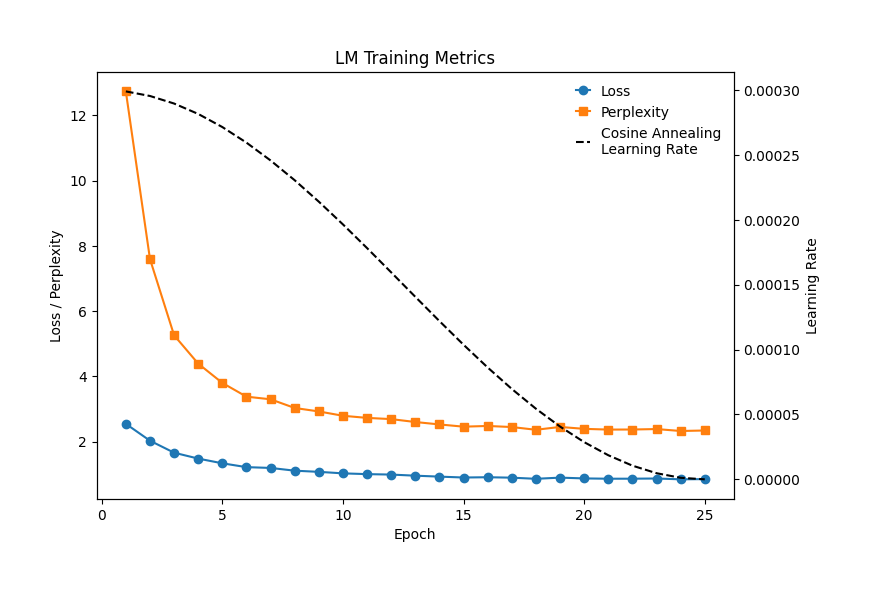

In [53]:
#@markdown ---
#@markdown # Train LM
#@markdown ---

from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

BATCH = 128
EPOCHS = 25
LR = 3e-4
WD = 1e-2
USE_AMP = torch.cuda.is_available()

ds = LMDataset(seqs, LM_MAX_LEN)
dl = DataLoader(ds, batch_size=BATCH, shuffle=True, num_workers=0, pin_memory=True)

opt = AdamW(lm.parameters(), lr=LR, weight_decay=WD)
sched = CosineAnnealingLR(opt, T_max=EPOCHS)
loss_fn = nn.CrossEntropyLoss(ignore_index=LM_PAD)
scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)

# ----------------------------
# Metric tracking (per-epoch)
# ----------------------------
epoch_losses = []
epoch_ppls = []
epoch_lrs = []

lm.train()
for ep in range(EPOCHS):
    total = 0.0
    n = 0
    pbar = tqdm(dl, desc=f"LM epoch {ep+1}/{EPOCHS}")
    for inp, tgt in pbar:
        inp = inp.to(device, non_blocking=True)
        tgt = tgt.to(device, non_blocking=True)

        opt.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast(enabled=USE_AMP):
            logits = lm(inp)
            loss = loss_fn(logits.reshape(-1, LM_VOCAB), tgt.reshape(-1))

        scaler.scale(loss).backward()
        scaler.unscale_(opt)
        torch.nn.utils.clip_grad_norm_(lm.parameters(), 1.0)
        scaler.step(opt)
        scaler.update()

        total += float(loss.item())
        n += 1
        avg = total / n
        pbar.set_postfix(loss=f"{avg:.4f}", ppl=f"{math.exp(avg):.2f}", lr=f"{opt.param_groups[0]['lr']:.2e}")

    sched.step()
    avg = total / max(n, 1)
    print(f"epoch {ep+1}: loss={avg:.4f} | ppl={math.exp(avg):.2f} | lr={opt.param_groups[0]['lr']:.2e}")

    # record metrics once per epoch
    epoch_losses.append(avg)
    epoch_ppls.append(math.exp(avg))
    epoch_lrs.append(opt.param_groups[0]["lr"])

final_lm_loss = avg
print("Final ppl:", math.exp(final_lm_loss))

# ----------------------------
# Plot training curves
# ----------------------------
import matplotlib.pyplot as plt

epochs = range(1, len(epoch_losses) + 1)

fig, ax1 = plt.subplots(figsize=(8, 5))

# Left axis: loss + perplexity
line1, = ax1.plot(epochs, epoch_losses, marker="o", label="Loss")
line2, = ax1.plot(epochs, epoch_ppls, marker="s", label="Perplexity")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss / Perplexity")

# Right axis: learning rate
ax2 = ax1.twinx()
line3, = ax2.plot(epochs, epoch_lrs, linestyle="--", color="black", label="Cosine Annealing\nLearning Rate")
ax2.set_ylabel("Learning Rate")

# --- Combined legend ---
lines = [line1, line2, line3]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="upper right")

fig.tight_layout()
plt.title("LM Training Metrics")
plt.show()

In [54]:
#@markdown ---
#@markdown # Sampling + NLL (batched) — SAFE for PFAM domains
#@markdown ---

import numpy as np
import torch
import torch.nn.functional as F

# If seqs exists, set a domain-appropriate default min_len
if "seqs" in globals() and isinstance(seqs, (list, tuple)) and len(seqs) > 0:
    _lens = np.array([len(s) for s in seqs], dtype=int)
    DEFAULT_MIN_LEN = int(np.percentile(_lens, 10))  # 10th percentile
    DEFAULT_MIN_LEN = max(8, DEFAULT_MIN_LEN)
else:
    DEFAULT_MIN_LEN = 20

@torch.no_grad()
def sample_lm(
    lm,
    n: int = 256,
    max_new_tokens: int = 260,
    temperature: float = 0.85,
    top_p: float = 0.85,
    min_len: int = None,
):
    """
    Autoregressive nucleus sampling with:
      - automatic cap to model capacity
      - EOS disallowed until min_len reached (optional)
      - per-sequence early stop once EOS sampled
    Returns token tensor shape (n, T) including BOS and maybe EOS.
    """
    lm.eval()

    if min_len is None:
        min_len = DEFAULT_MIN_LEN

    # Model capacity (input tokens length T the model can accept)
    # Your TinyGPT forward() effectively limits T to ~ (lm.max_seq_len - 1).
    model_cap = int(getattr(lm, "max_seq_len", LM_MAX_LEN_INP))
    max_steps = min(int(max_new_tokens), max(1, model_cap - 1))

    x = torch.full((n, 1), LM_BOS, dtype=torch.long, device=device)
    finished = torch.zeros(n, dtype=torch.bool, device=device)

    for _ in range(max_steps):
        # Only compute logits for unfinished sequences
        if finished.any():
            x_in = x[~finished]
        else:
            x_in = x

        logits = lm(x_in)[:, -1, :] / max(float(temperature), 1e-6)

        cur_len = x.shape[1]  # includes BOS
        # Disallow EOS until (cur_len-1) residues >= min_len
        # (cur_len-1 is current AA length excluding BOS)
        if (cur_len - 1) < int(min_len):
            logits[:, LM_EOS] = -1e9

        probs = F.softmax(logits, dim=-1)

        # nucleus (top-p)
        sorted_probs, sorted_idx = torch.sort(probs, descending=True, dim=-1)
        cdf = torch.cumsum(sorted_probs, dim=-1)

        # keep smallest set whose cumulative prob <= top_p
        cutoff = cdf > float(top_p)
        cutoff[..., 0] = False
        sorted_probs = sorted_probs.masked_fill(cutoff, 0.0)

        # guard: if everything got zeroed (can happen at extreme top_p), fall back to argmax
        denom = sorted_probs.sum(dim=-1, keepdim=True)
        bad = denom.squeeze(-1) <= 0
        if bad.any():
            # for bad rows: pick max prob token directly from original probs
            next_id_bad = probs[bad].argmax(dim=-1)
            # for good rows: sample normally
            sorted_probs[~bad] = sorted_probs[~bad] / denom[~bad]
            next_id_good = sorted_idx[~bad].gather(
                -1, torch.multinomial(sorted_probs[~bad], num_samples=1)
            ).squeeze(-1)

            next_id = torch.empty((logits.shape[0],), device=device, dtype=torch.long)
            next_id[bad] = next_id_bad
            next_id[~bad] = next_id_good
        else:
            sorted_probs = sorted_probs / denom
            next_id = sorted_idx.gather(
                -1, torch.multinomial(sorted_probs, num_samples=1)
            ).squeeze(-1)

        # Scatter next tokens back into full batch
        next_full = torch.full((n,), LM_PAD, device=device, dtype=torch.long)
        next_full[~finished] = next_id

        x = torch.cat([x, next_full[:, None]], dim=1)
        finished |= (next_full == LM_EOS)
        if finished.all():
            break

    return x

def decode_tokens(tokens_1d):
    toks = [int(t) for t in tokens_1d]
    out = []
    for t in toks:
        if t in (LM_BOS, LM_PAD):
            continue
        if t == LM_EOS:
            break
        aa = lm_id_to_aa.get(t, "")
        if len(aa) == 1:
            out.append(aa)
    return "".join(out)

@torch.no_grad()
def lm_nll_batch(lm, seq_list, max_len: int = None):
    """
    Average NLL per non-PAD token for a list of sequences.
    By default uses LM_MAX_LEN (your training encode length).
    """
    lm.eval()
    if max_len is None:
        max_len = LM_MAX_LEN

    X = np.stack([lm_encode(s, max_len) for s in seq_list], axis=0)  # (N, L)
    inp = torch.tensor(X[:, :-1], device=device, dtype=torch.long)
    tgt = torch.tensor(X[:, 1:], device=device, dtype=torch.long)

    logits = lm(inp)  # (N, T, V)
    logp = F.log_softmax(logits, dim=-1)

    mask = (tgt != LM_PAD)
    nll = -(logp.gather(-1, tgt.unsqueeze(-1)).squeeze(-1) * mask).sum(dim=1)
    denom = mask.sum(dim=1).clamp(min=1)
    return (nll / denom).detach().float().cpu().numpy()

# quick smoke test (safe defaults for PFAM domains)
toks = sample_lm(lm, n=5, max_new_tokens=LM_MAX_LEN-1, min_len=DEFAULT_MIN_LEN)
for i in range(5):
    s = decode_tokens(toks[i])
    print(i, "len", len(s), "seq_head", s[:])

0 len 71 seq_head MAVEKTNSSSSLAEVIDRILDKGIVIDAWARVSLVGIELLAIEARVVIASVETYLKYAEAVGLTQSAAVPA
1 len 62 seq_head MTVVERREIALVDLLDRLLAGGVVITGDITLRIADVDLVRIDLNALISSVNAQVPSPFEELL
2 len 62 seq_head MTAALPERRVALVDLLDRVLAGGVVITGEITLSIADVDLVRISLRALIASVRVENEEGGDGR
3 len 62 seq_head MTVVERREIALVDLLDRLLAGGVVITGDITLRIADVDLVRIDLNALISSVNAQVPSPFEELL
4 len 71 seq_head MAVEKTNSSSSLAEVIDRILDKGIVIDAWARVSLVGIELLAIEARVVIASVETYLKYAEAVGLTQSAAVPA


In [55]:
#@markdown ---
#@markdown # Filters + novelty (single motif requirement + k-mer novelty)
#@markdown ---
import re
from collections import Counter

# ----------------------------
# Single motif requirement (UI)
# ----------------------------
REQUIRE_MOTIF = False  #@param {type:"boolean"}

MOTIF_PATTERN = ""  #@param {type:"string"}  # e.g. C..C (regex) or GYG (literal)
MOTIF_MATCH = "regex"  #@param ["regex", "literal"]
MOTIF_RULE = "anywhere"  #@param ["anywhere", "window", "exact"]

# Positions are 1-indexed (biologist-friendly)
MOTIF_POS_MIN = 1    #@param {type:"integer"}
MOTIF_POS_MAX = 999  #@param {type:"integer"}
MOTIF_POS_EXACT = 1  #@param {type:"integer"}

def _find_motif_starts(seq: str, pattern: str, match: str = "regex"):
    """Return list of 0-indexed start positions where motif matches."""
    if not seq or not pattern:
        return []
    if match == "literal":
        starts = []
        i = seq.find(pattern)
        while i != -1:
            starts.append(i)
            i = seq.find(pattern, i + 1)
        return starts
    return [m.start() for m in re.finditer(pattern, seq)]

def motif_pass(seq: str) -> bool:
    """
    Single motif check.
    - If REQUIRE_MOTIF is False: always pass
    - If MOTIF_PATTERN is blank: treat as no motif defined -> pass
    """
    if not REQUIRE_MOTIF:
        return True

    pat = (MOTIF_PATTERN or "").strip()
    if not pat:
        return True

    starts = _find_motif_starts(seq, pat, match=MOTIF_MATCH)
    if not starts:
        return False

    if MOTIF_RULE == "anywhere":
        return True

    if MOTIF_RULE == "window":
        return any(MOTIF_POS_MIN <= (s + 1) <= MOTIF_POS_MAX for s in starts)

    if MOTIF_RULE == "exact":
        return any((s + 1) == MOTIF_POS_EXACT for s in starts)

    return False  # fail closed

print(
    f"[motif] REQUIRE_MOTIF={REQUIRE_MOTIF} | "
    f"pattern='{MOTIF_PATTERN}' | match={MOTIF_MATCH} | rule={MOTIF_RULE}"
)

# ----------------------------
# Basic sequence sanity filters
# (function name kept as `basic_filters` to match your generator)
# ----------------------------
def max_aa_fraction(seq: str) -> float:
    """Max single-AA fraction (low complexity indicator)."""
    if not seq:
        return 1.0
    c = Counter(seq)
    return max(v / len(seq) for v in c.values())

def basic_filters(
    seq: str,
    min_len: int,
    max_len: int,
max_cys: int = 4,
    max_lowcomplex_run: int = 6,
    max_single_aa_frac: float = 0.25,
) -> bool:
    if not seq:
        return False

    L = len(seq)
    if L < min_len or L > max_len:
        return False

    if seq.count("C") > max_cys:
        return False

    # Single motif requirement (toggle)
    if not motif_pass(seq):
        return False

    # Homopolymer runs (include E/D)
    run_pat = r"(A{%d,}|G{%d,}|S{%d,}|T{%d,}|P{%d,}|E{%d,}|D{%d,})" % ((max_lowcomplex_run,) * 7)
    if re.search(run_pat, seq):
        return False

    if max_aa_fraction(seq) > max_single_aa_frac:
        return False

    return True

# ----------------------------
# k-mer utilities + novelty stats
# (TRAIN_K and novelty_kmer_fraction names match your generator)
# ----------------------------
def kmer_set(seq: str, k: int) -> set:
    """All unique contiguous k-mers in seq."""
    L = len(seq)
    if L < k:
        return set()
    return {seq[i:i+k] for i in range(L - k + 1)}

TRAIN_K = kmer_size  # expects kmer_size defined elsewhere

def build_train_kmers(train_seqs, k: int) -> set:
    km = set()
    for s in train_seqs:
        if s:
            km |= kmer_set(s, k)
    return km

train_kmers: set = build_train_kmers(seqs, TRAIN_K)  # expects seqs defined elsewhere
print(f"[kmer] TRAIN_K={TRAIN_K} | seqs={len(seqs)} | train_kmers={len(train_kmers):,}")

def novelty_kmer_fraction(seq: str, k: int | None = None) -> float:
    """Fraction of k-mers in `seq` that are present in training."""
    if k is None:
        k = TRAIN_K
    ks = kmer_set(seq, k)
    if not ks:
        return 0.0
    return len(ks & train_kmers) / len(ks)

def novelty_unseen_kmer_count(seq: str, k: int | None = None) -> int:
    """Count of k-mers in `seq` that are NOT present in training."""
    if k is None:
        k = TRAIN_K
    ks = kmer_set(seq, k)
    if not ks:
        return 0
    return len(ks - train_kmers)

def novelty_unseen_kmer_fraction(seq: str, k: int | None = None) -> float:
    """Fraction of k-mers in `seq` that are NOT present in training."""
    if k is None:
        k = TRAIN_K
    ks = kmer_set(seq, k)
    if not ks:
        return 0.0
    return len(ks - train_kmers) / len(ks)

def novelty_report(seq: str, k: int | None = None) -> dict:
    """Convenience: return multiple novelty stats for a single sequence."""
    if k is None:
        k = TRAIN_K
    ks = kmer_set(seq, k)
    if not ks:
        return {"k": k, "n_kmers": 0, "seen_frac": 0.0, "unseen_frac": 0.0, "unseen_count": 0}
    seen = len(ks & train_kmers)
    unseen = len(ks) - seen
    return {
        "k": k,
        "n_kmers": len(ks),
        "seen_frac": seen / len(ks),
        "unseen_frac": unseen / len(ks),
        "unseen_count": unseen,
    }

# Optional sanity checks:
# print("[motif] pass seq0:", motif_pass(seqs[0]))
# print("[kmer] report seq0:", novelty_report(seqs[0]))

[motif] REQUIRE_MOTIF=False | pattern='' | match=regex | rule=anywhere
[kmer] TRAIN_K=7 | seqs=1929 | train_kmers=27,077


In [56]:


#@markdown ---
#@markdown # Generate, Filter,Rank, Print Seqs, write to JSON
#@markdown ---
import os, json, textwrap, time
import numpy as np
import torch
from tqdm.auto import tqdm

def have_regressor():
    return all(name in globals() for name in ["model", "encode_seq", "max_len"])

@torch.no_grad()
def regressor_predict_batch(reg_model, seq_list, max_len, device=device):
    reg_model.eval()
    X = np.stack([encode_seq(s, max_len) for s in seq_list], axis=0)
    xt = torch.tensor(X, dtype=torch.long, device=device)
    preds = reg_model(xt).detach().float().cpu().numpy()
    return preds.reshape(-1)

def generate_rank_select(
    n_accept=200,
    batch=512,
    temperature=0.85,
    top_p=0.85,
    min_len=180,
    seq_max_len=260,
    nll_thr=3.2,
    novelty_soft_thr=0.995,     # gentle: only reject near-copies
    max_sampled=200_000,
    rank_keep=50,
    final_keep=10,
    novelty_weight=25.0,        # used when regressor absent
    status_every=10_000,        # print a line every N sampled
    auto_relax=True,            # relax novelty gate if acceptance is too low
):
    candidates = []
    seen = set()
    total_sampled = 0

    reject_basic = reject_nll = reject_dup = reject_novelty = reject_empty = 0
    t0 = time.time()

    print("Starting generation pipeline...")
    print(f"Target accepted: {n_accept} | batch={batch} | T={temperature} | top_p={top_p}")
    print(f"Filters: min_len={min_len}, max_len={seq_max_len}, nll_thr={nll_thr}, novelty_soft_thr={novelty_soft_thr}")
    print("-" * 70)

    pbar = tqdm(total=n_accept, desc="Accepted sequences", smoothing=0.05)

    while len(candidates) < n_accept and total_sampled < max_sampled:
        toks = sample_lm(lm, n=batch, temperature=temperature, top_p=top_p, min_len=min_len)
        seq_batch = [decode_tokens(toks[i]) for i in range(toks.shape[0])]
        total_sampled += len(seq_batch)

        # periodic print even if tqdm rendering is weird
        if (total_sampled % status_every) < batch:
            dt = time.time() - t0
            rate = total_sampled / max(dt, 1e-6)
            acc = len(candidates)
            print(f"[status] sampled={total_sampled:,} accepted={acc} "
                  f"rej_basic={reject_basic} rej_nll={reject_nll} rej_dup={reject_dup} rej_nov={reject_novelty} "
                  f"({rate:.1f} seq/s)")

        # cheap prefilter: non-empty + dedup
        kept0 = []
        for s in seq_batch:
            if not s or len(s) < min_len:
                reject_empty += 1
                continue
            if s in seen:
                reject_dup += 1
                continue
            kept0.append(s)

        # basic + novelty gate
        kept = []
        for s in kept0:
            if not basic_filters(s, min_len=min_len, max_len=seq_max_len):
                reject_basic += 1
                continue
            kf = novelty_kmer_fraction(s, TRAIN_K)
            if kf > novelty_soft_thr:
                reject_novelty += 1
                continue
            kept.append(s)

        if not kept:
            pbar.set_postfix(sampled=total_sampled, rej_basic=reject_basic, rej_nll=reject_nll, rej_dup=reject_dup, rej_nov=reject_novelty)
            # auto-relax if we’re making no progress for a long time
            if auto_relax and total_sampled > 50_000 and len(candidates) < max(5, n_accept // 20):
                novelty_soft_thr = min(0.9995, novelty_soft_thr + 0.0005)
            continue

        # batched NLL (fast)
        nlls = lm_nll_batch(lm, kept)
        for s, nll in zip(kept, nlls):
            if nll > nll_thr:
                reject_nll += 1
                continue
            seen.add(s)
            candidates.append(s)
            pbar.update(1)
            if len(candidates) >= n_accept:
                break

        pbar.set_postfix(sampled=total_sampled, rej_basic=reject_basic, rej_nll=reject_nll, rej_dup=reject_dup, rej_nov=reject_novelty)

        # auto-relax novelty gate if acceptance is truly too low
        if auto_relax and total_sampled > 80_000:
            acc_rate = len(candidates) / max(total_sampled, 1)
            if acc_rate < 0.001:  # <0.1% acceptance
                novelty_soft_thr = min(0.9995, novelty_soft_thr + 0.0005)

    pbar.close()

    if len(candidates) == 0:
        raise RuntimeError(
            "No sequences accepted.\n"
            "Try: increase nll_thr (e.g., 3.6), raise novelty_soft_thr (e.g., 0.998–0.9995), "
            "relax basic_filters, or reduce min_len."
        )

    print("\n--- Summary ---")
    print(f"Sampled: {total_sampled:,} | Accepted: {len(candidates)}")
    print(f"Rejected empty/short: {reject_empty}")
    print(f"Rejected basic: {reject_basic} | nll: {reject_nll} | dup: {reject_dup} | novelty: {reject_novelty}")

    # metrics for ranking
    cand_nll = lm_nll_batch(lm, candidates)
    cand_kf  = np.array([novelty_kmer_fraction(s, TRAIN_K) for s in candidates], dtype=float)

    if have_regressor():
        print("Using regressor for ranking (model + encode_seq + max_len detected)")
        pred = regressor_predict_batch(model, candidates, max_len=max_len, device=device)
        keep_idx = np.argsort(-pred)[:rank_keep]
        ranked = [{"seq": candidates[i], "pred": float(pred[i]), "nll": float(cand_nll[i]), "kmer_frac": float(cand_kf[i])}
                  for i in keep_idx]
        ranked = sorted(ranked, key=lambda d: d["pred"], reverse=True)[:final_keep]
    else:
        print("No regressor found; ranking by proxy: (-NLL) - novelty_weight*kmer_frac")
        proxy = (-np.array(cand_nll)) - novelty_weight * cand_kf
        keep_idx = np.argsort(-proxy)[:rank_keep]
        ranked = [{"seq": candidates[i], "proxy": float(proxy[i]), "nll": float(cand_nll[i]), "kmer_frac": float(cand_kf[i])}
                  for i in keep_idx]
        ranked = sorted(ranked, key=lambda d: d["proxy"], reverse=True)[:final_keep]

    # Print final 10
    print("\n=== FINAL 10 SEQUENCES ===")
    for j, d in enumerate(ranked, 1):
        s = d["seq"]
        extra = (f"pred={d['pred']:.4f}" if "pred" in d else f"proxy={d['proxy']:.4f}")
        print(f"\n[{j}] len={len(s)}  nll={d['nll']:.3f}  kmer_frac={d['kmer_frac']:.3f}  {extra}")
        print(s)

    # Write FASTA
    with open("top10.fasta", "w") as f:
        for j, d in enumerate(ranked, 1):
            s = d["seq"]
            header = f"top{j:02d}|len={len(s)}|nll={d['nll']:.3f}|kmer={d['kmer_frac']:.3f}"
            header += f"|pred={d['pred']:.4f}" if "pred" in d else f"|proxy={d['proxy']:.4f}"
            f.write(f">{header}\n{s}\n")

    # Write AlphaFold3 JSON inputs (one per sequence)
    os.makedirs("af3_inputs", exist_ok=True)
    modelSeeds = [1]

    for j, d in enumerate(ranked, 1):
        s = d["seq"]
        af3 = {
            "name": f"FP_TinyGPT_top{j:02d}",
            "modelSeeds": modelSeeds,
            "sequences": [
                {"protein": {"id": "A", "sequence": s}}
            ]
        }
        with open(f"af3_inputs/fold_input_top{j:02d}.json", "w") as f:
            json.dump(af3, f, indent=2)

    print("\nWrote: top10.fasta")
    print("Wrote: af3_inputs/fold_input_top01.json ... fold_input_top10.json")
    return ranked

top10 = generate_rank_select(
    n_accept=N_ACCEPT,
    batch=BATCH_SIZE,
    temperature=TEMPERATURE,
    top_p=TOP_P,
    min_len=MIN_LEN,
    nll_thr=NLL_THRESHOLD,
    novelty_soft_thr=NOVELTY_SOFT_THRESHOLD,
    max_sampled=MAX_SAMPLED,
    rank_keep=RANK_KEEP,
    final_keep=FINAL_KEEP,
    novelty_weight=NOVELTY_WEIGHT,
    status_every=STATUS_EVERY,
    auto_relax=AUTO_RELAX,
)


Starting generation pipeline...
Target accepted: 100 | batch=1024 | T=0.7 | top_p=0.9
Filters: min_len=20, max_len=260, nll_thr=3.1, novelty_soft_thr=0.9
----------------------------------------------------------------------


Accepted sequences:   0%|          | 0/100 [00:00<?, ?it/s]

[status] sampled=1,024 accepted=0 rej_basic=0 rej_nll=0 rej_dup=0 rej_nov=0 (142.3 seq/s)
[status] sampled=2,048 accepted=59 rej_basic=0 rej_nll=0 rej_dup=0 rej_nov=965 (142.4 seq/s)

--- Summary ---
Sampled: 2,048 | Accepted: 100
Rejected empty/short: 0
Rejected basic: 0 | nll: 0 | dup: 0 | novelty: 1933
No regressor found; ranking by proxy: (-NLL) - novelty_weight*kmer_frac

=== FINAL 10 SEQUENCES ===

[1] len=75  nll=0.270  kmer_frac=0.754  proxy=-0.6464
MTAALVPWDSGPLGVPYEGVPLVDLLDRVLATGVVISGDLVIAIADVPLVRLSLHALLSSVNERVPAPWADGGPL

[2] len=70  nll=0.244  kmer_frac=0.891  proxy=-0.6894
MTRAIERREVALVDLLDRVLAGGVVIAGEITLSIADIDLVRISLRALIASVRVENEEGREGDRDDRRRRG

[3] len=70  nll=0.256  kmer_frac=0.875  proxy=-0.6936
MTRVIERREVALVDLLDRVLAGGVVIAGEITLSIADIDLVRISLRALIASVRVENEEGREGDRRDGRRDG

[4] len=66  nll=0.288  kmer_frac=0.817  proxy=-0.6963
MTAEPPGPLAHQQVALVDLLDRLLAGGVVITGDLTLRIADVDLVRIDLRALISSVNANVPSPWEEP

[5] len=66  nll=0.289  kmer_frac=0.817  proxy=-0.6978
MTAPPAGPLAQQQIALVDVLDRLLAGGVVITGD

In [57]:
#@markdown ---
#@markdown # Download Dependencies to Generate MSA
#@markdown ---


RUN_INSTALL = True
if RUN_INSTALL:
    print("Downloading dependencies...\n")

    from tqdm.auto import tqdm
    import subprocess

    steps = [
        ["apt-get", "-qq", "update"],
        ["apt-get", "-qq", "install", "-y", "mafft"],
        ["pip", "-q", "install", "pymsaviz"],
        ["pip", "-q", "install", "biopython"],
    ]

    with tqdm(
        total=len(steps),
        desc="",
        bar_format="{bar} {n_fmt}/{total_fmt}",
        colour="cyan",
    ) as pbar:
        for cmd in steps:
            subprocess.run(cmd, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL, check=True)
            pbar.update(1)


           0/4


Consensus:
MTAXPXAPVPWDSXXXXXPXRXVALVDLLDRVLAGGVVIXGXXTLXIADXDLVRISLRALIXSVXXXXXXXXEGDRDDGRXXGXX


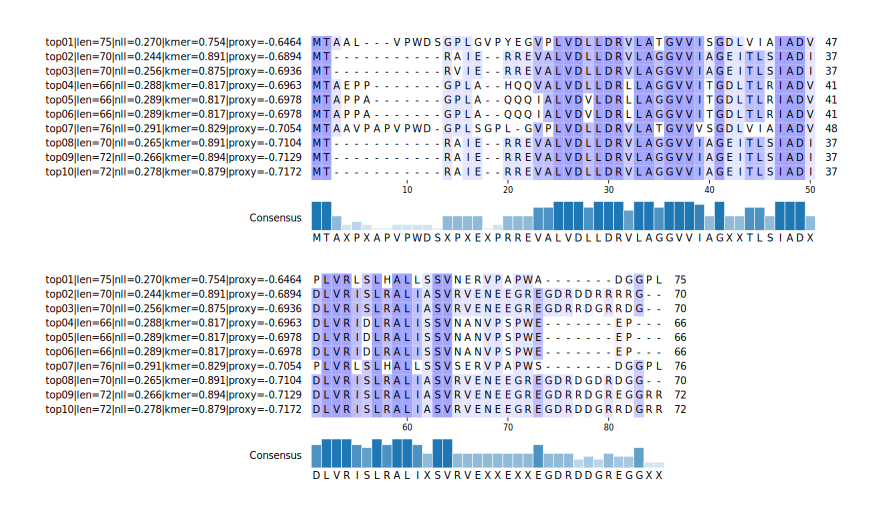

In [58]:
#@markdown ---
#@markdown # Run MAFFT MSA on the multi-FASTA
#@markdown ---

import os
import subprocess
from datetime import datetime
import tempfile
from collections import Counter

from Bio import SeqIO, AlignIO
from Bio.SeqRecord import SeqRecord
from Bio.Seq import Seq

try:
    from pymsaviz import MsaViz
except ImportError:
    MsaViz = None

from IPython.display import SVG, display


#@markdown ---
#@markdown ## Inputs / Outputs
#@markdown ---
multifasta_path = "top10.fasta"  #@param {type:"string"}
INPUT_FASTA = multifasta_path


#@markdown ---
#@markdown ## Visualization
#@markdown ---
WRAP_LENGTH = 50               #@param {type:"integer"}
CONSENSUS_THRESHOLD = 0.501    #@param {type:"number"}
MAKE_SVG = True                #@param {type:"boolean"}

# Always do U->X; do NOT use --anysymbol
REPLACE_U_WITH_X = True
USE_ANY_SYMBOL = False


def consensus_from_alignment(msa, threshold=0.501, gap_char="-"):
    L = msa.get_alignment_length()
    out = []
    for col in range(L):
        syms = [rec.seq[col] for rec in msa]
        non_gaps = [c for c in syms if c != gap_char]
        if not non_gaps:
            out.append(gap_char)
            continue
        counts = Counter(non_gaps)
        top, n = counts.most_common(1)[0]
        out.append(top if (n / len(non_gaps)) >= threshold else "X")
    return "".join(out)


def run_basic_msa(input_fasta_path: str):
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

    with tempfile.TemporaryDirectory() as tmpdir:
        cleaned_fasta = os.path.join(tmpdir, "cleaned.fasta")
        aligned_fasta = os.path.join(tmpdir, "aligned.fasta")

        # --- Clean FASTA ---
        cleaned = []
        allowed = set("ACDEFGHIKLMNPQRSTVWYXBZJO-")

        for rec in SeqIO.parse(input_fasta_path, "fasta"):
            seq = str(rec.seq).upper()
            if REPLACE_U_WITH_X:
                seq = seq.replace("U", "X")
            seq = "".join(c for c in seq if c in allowed)
            if seq:
                cleaned.append(SeqRecord(Seq(seq), id=rec.id[:50], description=""))

        SeqIO.write(cleaned, cleaned_fasta, "fasta")

        # --- Run MAFFT ---
        mafft = ["mafft", "--auto", cleaned_fasta]
        proc = subprocess.run(mafft, capture_output=True, text=True)
        if proc.returncode != 0:
            raise RuntimeError(proc.stderr or "MAFFT failed")

        # Save MAFFT output to temp file for Biopython
        with open(aligned_fasta, "w", encoding="utf-8") as f:
            f.write(proc.stdout)

        alignment = AlignIO.read(aligned_fasta, "fasta")
        consensus = consensus_from_alignment(alignment, float(CONSENSUS_THRESHOLD))

        print("\nConsensus:")
        print(consensus)

        # --- Display SVG directly (no file writing) ---
        if MAKE_SVG and MsaViz is not None:
            viz = MsaViz(
                aligned_fasta,
                wrap_length=int(WRAP_LENGTH),
                show_label=True,
                show_count=True,
                show_consensus=True,
                color_scheme="Identity",

            )

            # Display without saving
            try:
                svg_text = viz.to_svg()
                display(SVG(data=svg_text))
            except:
                viz.savefig("temp.svg")
                display(SVG(filename="temp.svg"))

run_basic_msa(INPUT_FASTA)